In [2]:
import numpy as np
import json
from imageio.v2 import imread
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from tqdm import tqdm
from scipy.ndimage import zoom
from holodoppler.utils import normalize, create_holo


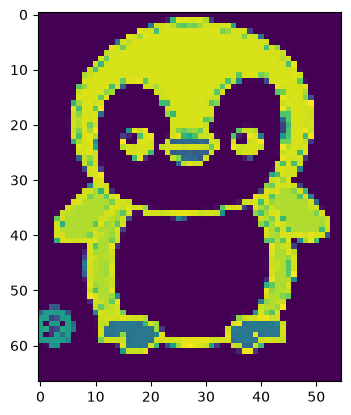

In [3]:
img = imread("../debug_outputs/penguin.png")

img = 255-np.mean(img, axis=-1)
img = img.astype(np.uint8)

img = np.pad(img, ((0,0),(0,0)))

img = zoom(img,1/5)

plt.imshow(img)

In [52]:
z = 0.5 # distance centre de l'objet à caméra
wavelength = 852e-9
camera_pixel_pitch = np.array([20e-6, 20e-6]) # distance entre deux pixels caméra
camera_width = 512
camera_height = 512
object_pixel_pitch = np.array([20e-6, 20e-6]) # height pitch  width pitch
position_center_object = np.array([0.0, 0.0, -z]) # x y z dans l'espace
normal_object = np.array([0.0, 0.0, 1.0]) # normal vector of object plane
angle_object = 0.0 # deg angle of rotation on the normal vector
position_center_camera = np.array([0, 0, 0])
normal_camera = np.array([0,0,1])
angle_camera = 0.0 # deg 
normal_reference = np.array([0,0.0,1])
reference_angle = 1 #deg
reference_rotate_vector = np.array([1,0,0])
normal_reference = normal_reference * np.cos(reference_angle * np.pi / 180) + np.cross(reference_rotate_vector, normal_reference) * np.sin(reference_angle * np.pi / 180) + reference_rotate_vector * np.dot(reference_rotate_vector, normal_reference) * (1 - np.cos(reference_angle * np.pi / 180))
normal_reference /= np.linalg.norm(normal_reference)
ref_amplitude = 10

In [53]:
from holo_simple import HologramSimulator, Grid
# coordonnées de l'objet
N, M = np.shape(img)[-2:]
object_grid = Grid(N, M, object_pixel_pitch)
object_grid.generate_coordinates()
object_grid.transform(angle_object, normal_object, position_center_object)

# coordonnées de la caméra
P, Q = camera_height, camera_width
camera_grid = Grid(P, Q, camera_pixel_pitch)
camera_grid.generate_coordinates()
camera_grid.transform(angle_camera, normal_camera, position_center_camera)

# coordonnées de la référence
sim = HologramSimulator(wavelength)
Int, Obj, Ref  = sim.generate_hologram_cdist(img, object_grid, camera_grid, normal_reference, ref_amplitude)
print(np.sum(Int), np.sum(np.abs(Obj)**2), np.sum(np.abs(Ref)**2))

38027611.94062432 11816503.862254255 26214400.0


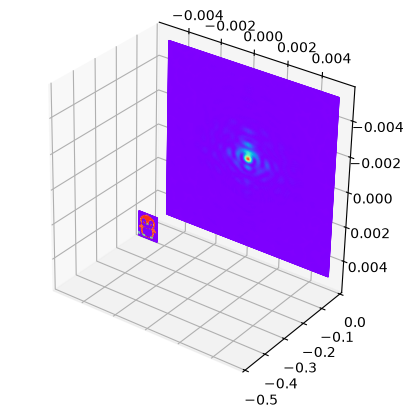

In [32]:
ax = plt.figure().add_subplot(projection='3d')
ax.view_init(elev=-45, azim=-45, roll=-56)
# ax.scatter(coordinates[...,0],coordinates[...,1],coordinates[...,2])

colors = plt.get_cmap("rainbow")(normalize(img))

ax.plot_surface(object_grid.coordinates[...,0],object_grid.coordinates[...,1],object_grid.coordinates[...,2], rstride=1, cstride=1, facecolors = colors, shade=False)


colors = plt.get_cmap("rainbow")(normalize(np.abs(Int)))

ax.plot_surface(camera_grid.coordinates[...,0],camera_grid.coordinates[...,1],camera_grid.coordinates[...,2], rstride=1, cstride=1, facecolors = colors, shade=False)

plt.show()


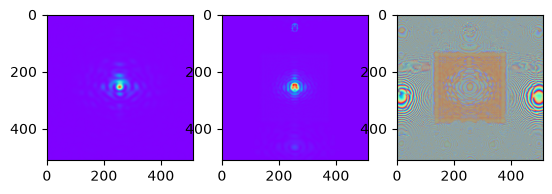

In [33]:
# fig, ax = plt.subplots(nrows=3, ncols=2)
# ax[0, 0].imshow(Int, cmap=plt.get_cmap("rainbow"))
# # ax[0, 1].imshow(np.abs(O))
# ax[1, 0].imshow(np.abs(Ref), cmap=plt.get_cmap("rainbow"))
# ax[1, 1].imshow(np.angle(Ref), cmap=plt.get_cmap("rainbow"))
# ax[2, 0].imshow(np.abs(Obj), cmap=plt.get_cmap("rainbow"))
# ax[2, 1].imshow(np.angle(Obj), cmap=plt.get_cmap("rainbow"))
# plt.show()

 # Fresnel propagation of the recoded Intensity frame
ppy, ppx = camera_pixel_pitch
ny, nx = camera_height, camera_width

def build_kernel_in(ny, nx, ppy, ppx, wavelength, z):
    y = (np.arange(0, ny) - np.round(ny / 2)) * ppy
    x = (np.arange(0, nx) - np.round(nx / 2)) * ppx
    X, Y = np.meshgrid(x, y)
    kernel_in = np.exp(1j * np.pi / (wavelength * z) * (X**2 + Y**2)).astype(np.complex64)
    return kernel_in

def build_kernel_out(ny, nx, ppy, ppx, wavelength, z):
    fx = np.fft.fftfreq(nx, d=ppx)
    fx = np.fft.fftshift(fx)
    fy = np.fft.fftfreq(ny, d=ppy)
    fy = np.fft.fftshift(fy)
    FX, FY = np.meshgrid(fx, fy)

    X = wavelength * z * FX
    Y = wavelength * z * FY
    phase = 1j * np.pi / (wavelength * z) * (X**2 + Y**2)
    kernel_out = (
                np.exp(1j * 2 * np.pi / wavelength * z) / (1j * wavelength * z) * np.exp(phase)
        ).astype(np.complex64)
    return kernel_out

kernel_in = build_kernel_in(ny, nx, ppy, ppx, wavelength, z)
kernel_out = build_kernel_out(ny, nx, ppy, ppx, wavelength, z)

fresnel_propagated = np.fft.fftshift(
        np.fft.fft2(Int * kernel_in, axes=(-1, -2), norm="ortho"), axes=(-1, -2)
    ) * kernel_out


fig, ax = plt.subplots(nrows=1, ncols=3)
ax[0].imshow(Int, cmap=plt.get_cmap("rainbow"))
# ax[0, 1].imshow(np.abs(O))
ax[1].imshow(np.abs(fresnel_propagated), cmap=plt.get_cmap("rainbow"))
ax[2].imshow(np.angle(fresnel_propagated), cmap=plt.get_cmap("rainbow"))
plt.show()

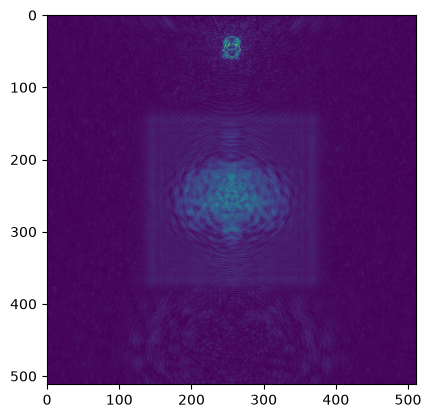

In [ ]:
from holodoppler.file_reader import HoloFileReader
from holodoppler.propagation import fresnel_transform


footer = {}
footer["compute_settings"] = {}
footer["compute_settings"]["image_rendering"] = {}
footer["compute_settings"]["image_rendering"]["lambda"] = wavelength
footer["compute_settings"]["image_rendering"]["propagation_distance"] = z  # you need to define this
footer["info"] = {}
footer["info"]["pixel_pitch"] = {}
footer["info"]["pixel_pitch"]["y"] = camera_pixel_pitch[0] / 1e-6
footer["info"]["pixel_pitch"]["x"] = camera_pixel_pitch[1] / 1e-6
footer["info"]["camera_fps"] = 1
create_holo("../debug_outputs/off_axis_example.holo", Int[np.newaxis,...], version=777, bit_depth=8, footer=footer)

reader = HoloFileReader("../debug_outputs/off_axis_example.holo")
frame = reader.read_frames(first_frame= 0, batch_size= 1)

propagated = fresnel_transform(np, np.fft, frame, z, (20e-6,20e-6), wavelength)

plt.imshow(np.abs(propagated[0]))


In [56]:
z = 0.5 # distance centre de l'objet à caméra
wavelength = 852e-9
camera_pixel_pitch = np.array([20e-6, 20e-6]) # distance entre deux pixels caméra
camera_width = 512
camera_height = 512
object_pixel_pitch = np.array([20e-6, 20e-6]) # height pitch  width pitch
position_center_object = np.array([0.0, 0.0, -z]) # x y z dans l'espace
normal_object = np.array([0.0, 0.0, 1.0]) # normal vector of object plane
angle_object = 0.0 # deg angle of rotation on the normal vector
position_center_camera = np.array([0, 0, 0])
normal_camera = np.array([0,0,1])
angle_camera = 0.0 # deg 
normal_reference = np.array([0,0.0,1])
reference_angle = 0 #deg
reference_rotate_vector = np.array([1,0,0])
normal_reference = normal_reference * np.cos(reference_angle * np.pi / 180) + np.cross(reference_rotate_vector, normal_reference) * np.sin(reference_angle * np.pi / 180) + reference_rotate_vector * np.dot(reference_rotate_vector, normal_reference) * (1 - np.cos(reference_angle * np.pi / 180))
normal_reference /= np.linalg.norm(normal_reference)
ref_amplitude = 10

In [57]:
from holo_simple import HologramSimulator, Grid
# coordonnées de l'objet
N, M = np.shape(img)[-2:]
object_grid = Grid(N, M, object_pixel_pitch)
object_grid.generate_coordinates()
object_grid.transform(angle_object, normal_object, position_center_object)

# coordonnées de la caméra
P, Q = camera_height, camera_width
camera_grid = Grid(P, Q, camera_pixel_pitch)
camera_grid.generate_coordinates()
camera_grid.transform(angle_camera, normal_camera, position_center_camera)

# coordonnées de la référence
sim = HologramSimulator(wavelength)
Int, Obj, Ref  = sim.generate_hologram_cdist(img, object_grid, camera_grid, normal_reference, ref_amplitude)
print(np.sum(Int), np.sum(np.abs(Obj)**2), np.sum(np.abs(Ref)**2))

37393268.22872509 11816503.862254255 26214400.0


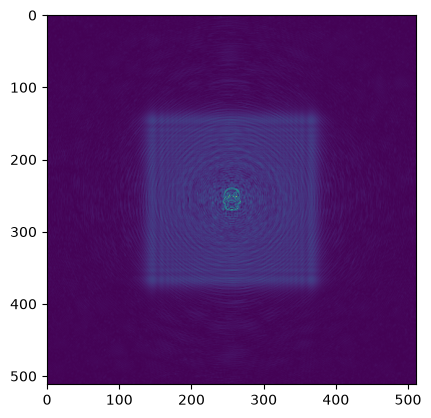

In [58]:
from holodoppler.file_reader import HoloFileReader
from holodoppler.propagation import fresnel_transform


footer = {}
footer["compute_settings"] = {}
footer["compute_settings"]["image_rendering"] = {}
footer["compute_settings"]["image_rendering"]["lambda"] = wavelength
footer["compute_settings"]["image_rendering"]["propagation_distance"] = z  # you need to define this
footer["info"] = {}
footer["info"]["pixel_pitch"] = {}
footer["info"]["pixel_pitch"]["y"] = camera_pixel_pitch[0] / 1e-6
footer["info"]["pixel_pitch"]["x"] = camera_pixel_pitch[1] / 1e-6
footer["info"]["camera_fps"] = 1
create_holo("../debug_outputs/on_axis_example.holo", Int[np.newaxis,...], version=777, bit_depth=8, footer=footer)

reader = HoloFileReader("../debug_outputs/on_axis_example.holo")
frame = reader.read_frames(first_frame= 0, batch_size= 1)

propagated = fresnel_transform(np, np.fft, frame, z, (20e-6,20e-6), wavelength)

plt.imshow(np.abs(propagated[0]))


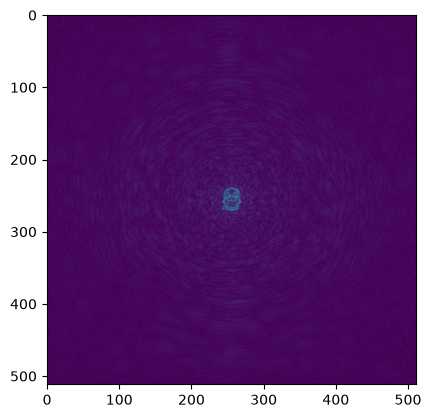

In [59]:
from holodoppler.file_reader import HoloFileReader
from holodoppler.propagation import fresnel_transform

data = np.stack([Int, np.abs(Ref)**2])

footer = {}
footer["compute_settings"] = {}
footer["compute_settings"]["image_rendering"] = {}
footer["compute_settings"]["image_rendering"]["lambda"] = wavelength
footer["compute_settings"]["image_rendering"]["propagation_distance"] = z  # you need to define this
footer["info"] = {}
footer["info"]["pixel_pitch"] = {}
footer["info"]["pixel_pitch"]["y"] = camera_pixel_pitch[0] / 1e-6
footer["info"]["pixel_pitch"]["x"] = camera_pixel_pitch[1] / 1e-6
footer["info"]["camera_fps"] = 1
create_holo("../debug_outputs/on_axis_dynamic_example.holo", data, version=777, bit_depth=8, footer=footer)

reader = HoloFileReader("../debug_outputs/on_axis_dynamic_example.holo")
frames = reader.read_frames(first_frame= 0, batch_size= 2)

propagated = fresnel_transform(np, np.fft, frames, z, (20e-6,20e-6), wavelength)

plt.imshow(np.abs(propagated[0]-propagated[1]))

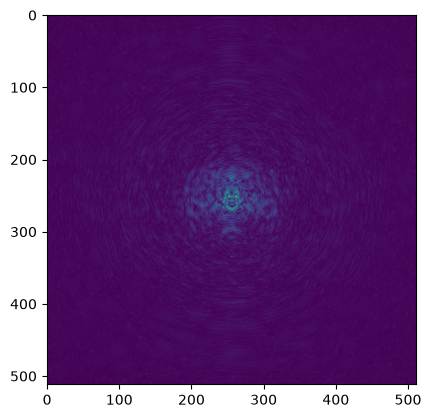

In [60]:
from holodoppler.file_reader import HoloFileReader
from holodoppler.propagation import fresnel_transform

data = np.stack([Int, np.abs(Ref)**2, np.abs(Obj)**2])

footer = {}
footer["compute_settings"] = {}
footer["compute_settings"]["image_rendering"] = {}
footer["compute_settings"]["image_rendering"]["lambda"] = wavelength
footer["compute_settings"]["image_rendering"]["propagation_distance"] = z  # you need to define this
footer["info"] = {}
footer["info"]["pixel_pitch"] = {}
footer["info"]["pixel_pitch"]["y"] = camera_pixel_pitch[0] / 1e-6
footer["info"]["pixel_pitch"]["x"] = camera_pixel_pitch[1] / 1e-6
footer["info"]["camera_fps"] = 1
create_holo("../debug_outputs/on_axis_dynamic_2_example.holo", data, version=777, bit_depth=8, footer=footer)

reader = HoloFileReader("../debug_outputs/on_axis_dynamic_2_example.holo")
frames = reader.read_frames(first_frame= 0, batch_size= 3)

propagated = fresnel_transform(np, np.fft, frames, z, (20e-6,20e-6), wavelength)

plt.imshow(np.abs(propagated[0]-propagated[1]-propagated[2]))